# Testing/prototyping notebook for ICECHIP simulation/PIPS comparisons and analyses

In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import numpy.ma as ma
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.ticker as ticker
import matplotlib.dates as dates
from mpl_toolkits.axes_grid1 import ImageGrid,make_axes_locatable,host_subplot
#from mpl_toolkits.basemap import Basemap
from datetime import datetime, timedelta
import sys
import os
import pyPIPS.utils as utils
import pyPIPS.thermolib as thermo
import pyPIPS.DSDlib as dsd
#import pyPIPS.disdrometer_module as dis
import pyPIPS.plotmodule as PIPSplot
import pyPIPS.simulator as sim
import pyPIPS.model_config as model_config
import pyPIPS.pips_io as pipsio
import pyPIPS.PIPS as pips
import pyPIPS.parsivel_params as pp
import pyPIPS.parsivel_qc as pqc
import pyPIPS.polarimetric as dualpol
import pyPIPS.timemodule as tm
from pyCRMtools.modules import plotmodule_xr as plotmod
from pyCRMtools.modules import utils as CRMutils
from pyCRMtools.pycaps import arps_read
from pyCRMtools.pycaps import pycaps_fields
# from pyCRMtools.pycaps import calvars_radar as radar
import pyPIPS.radarmodule as radar
import pandas as pd
import xarray as xr
import glob
import numpy.random as random
from scipy.stats import gamma, uniform
from scipy.special import gamma as gammafunc
from scipy import ndimage
from metpy.plots import StationPlot
from metpy.calc import wind_components
from metpy.cbook import get_test_data
from metpy.plots import StationPlot
from metpy.plots.wx_symbols import current_weather, sky_cover
from metpy.units import units
from metpy.plots import ctables
import warnings
warnings.simplefilter('ignore')
%matplotlib widget


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



In [2]:
# Define some functions for reading CM1 and COMMAS output
import pyart


def read_CM1(ncdir, prefix='cm1out', one_time_per_file=True):
    """Reads one or more CM1 netCDF files into an xarray Dataset

    Parameters
    ----------
    ncdir : str
        Directory where the CM1 netCDF file(s) reside
    prefix : str, optional
        CM1 file name prefix, by default 'cm1out'
    one_time_per_file : bool, optional
        Whether each output time is contained in a separate file, by default True

    Returns
    -------
    xarray.Dataset
        An xarray Dataset containing the data from the netCDF file(s)
    """

    # Construct the file path
    if one_time_per_file:
        cm1_filename = prefix + '_[0-9]*.nc'
    else:
        cm1_filename = prefix + '.nc'
    cm1_path = os.path.join(ncdir, cm1_filename)

    # Open up the netCDF file(s) using xarray
    # NOTE: passing decode_cf=False because encoding not present in CM1 output files
    if one_time_per_file:
        cm1_ds = xr.open_mfdataset(cm1_path, decode_cf=False)
    else:
        cm1_ds = xr.open_dataset(cm1_path, decode_cf=False)

    return cm1_ds

def read_COMMAS(ncdir, prefix='commasout', member=0, one_time_per_file=True):
    """Reads one or more COMMAS netCDF files into an xarray Dataset

    Parameters
    ----------
    ncdir : str
        Directory where the COMMAS netCDF file(s) reside
    prefix : str, optional
        COMMAS file name prefix, by default 'commasout'
    member : int, optional
        COMMAS ensemble member number, by default 0
    one_time_per_file : bool, optional
        Whether each output time is contained in a separate file, by default True

    Returns
    -------
    xarray.Dataset
        An xarray Dataset containing the data from the netCDF file(s)
    """

    # Construct the file path
    if one_time_per_file:
        commas_filename = prefix + '.[0-9]*.nc'
    else:
        commas_filename = prefix + f'.{member:03d}.000.nc'
    commas_path = os.path.join(ncdir, commas_filename)

    # Open up the netCDF file(s) using xarray
    # NOTE: passing decode_cf=False because encoding not present in COMMAS output files
    if one_time_per_file:
        commas_ds = xr.open_mfdataset(commas_path, decode_cf=False)
    else:
        commas_ds = xr.open_dataset(commas_path, decode_cf=False)

    return commas_ds


def read_sweeps(radname, radardir, radstarttime, radstoptime, fieldnames, el_req):
    """Reads sweeps from CFRadial files for a case"""
    radpathlist = glob.glob(radardir + f'/*{radname}*nc')

    # Now read in all the sweeps between radstarttime and radstoptime closest to the requested
    # elevation angle
    radstarttimedt = datetime.strptime(radstarttime, '%Y%m%d%H%M%S')
    radstoptimedt = datetime.strptime(radstoptime, '%Y%m%d%H%M%S')

    # outfieldnameslist = []
    radarsweeplist = []
    sweeptimelist = []

    for radpath in radpathlist:
        sweeptime1 = radar._getsweeptime(radpath)

        if radstarttimedt <= sweeptime1 and sweeptime1 <= radstoptimedt:
            # Note, the following may extract more than one sweep if there are multiple sweeps
            # with the same elevation angle in the file (i.e. as in SAILS mode)
            radarsweep1 = radar.readCFRadial_pyART(el_req, radpath, sweeptime1,
                                                  fieldnames, compute_kdp=False)
            for radarsweep in radarsweep1:
                radarsweeplist.append(radarsweep)
                # Extract time from start of each sweep
                sweep_time = pyart.graph.common.generate_radar_time_sweep(radarsweep, 0)
                sweeptimelist.append(sweep_time)

    # Sort the lists by increasing time since glob doesn't sort in any particular order
    sorted_sweeptimelist = sorted(sweeptimelist)
    sorted_radarsweeplist = [x for _, x in sorted(zip(sweeptimelist, radarsweeplist),
                                                  key=lambda pair: pair[0])]

    return sorted_sweeptimelist, sorted_radarsweeplist



In [3]:
case_config_path = '/Users/dawson29/Projects/pyPIPS/configs/ICECHIP_IOP12_2025_10s.py'
input_tag = None
dealias_vel = False
el_req_cl = None

# Dynamically import the case configuration file
utils.log("Case config file is {}".format(case_config_path))
config = utils.import_all_from(case_config_path)
try:
    config = utils.import_all_from(case_config_path)
    utils.log("Successfully imported case configuration parameters!")
except Exception:
    utils.fatal(
        "Unable to import case configuration parameters! Aborting!")

# Extract needed lists and variables from PIPS_IO_dict configuration dictionary
dataset_name = config.PIPS_IO_dict.get('dataset_name', None)
deployment_names = config.PIPS_IO_dict.get('deployment_names', None)
PIPS_dir = config.PIPS_IO_dict.get('PIPS_dir', None)
plot_dir = config.PIPS_IO_dict.get('plot_dir', None)
PIPS_types = config.PIPS_IO_dict.get('PIPS_types', None)
PIPS_names = config.PIPS_IO_dict.get('PIPS_names', None)
PIPS_filenames = config.PIPS_IO_dict.get('PIPS_filenames', None)
parsivel_combined_filenames = config.PIPS_IO_dict['PIPS_filenames_nc']
start_times = config.PIPS_IO_dict.get('start_times', [None] * len(PIPS_names))
end_times = config.PIPS_IO_dict.get('end_times', [None] * len(PIPS_names))
geo_locs = config.PIPS_IO_dict.get('geo_locs', [None] * len(PIPS_names))
requested_interval = config.PIPS_IO_dict.get('requested_interval', 10.)

# Extract needed lists and variables from the radar_dict configuration dictionary
comp_radar = config.radar_config_dict.get('comp_radar', False)
clean_radar = config.radar_config_dict.get('comp_radar', False)
calc_dualpol = config.radar_config_dict.get('calc_dualpol', False)
radar_name = config.radar_config_dict.get('radar_name', None)
radar_type = config.radar_config_dict.get('radar_type', None)
radar_dir = config.radar_config_dict.get('radar_dir', None)
radar_fname_pattern = config.radar_config_dict.get('radar_fname_pattern', None)
# Add the input filename tag to the pattern if needed
if input_tag:
    radar_fname_pattern = radar_fname_pattern.replace('.', '_{}.'.format(input_tag))
field_names = config.radar_config_dict.get('field_names', ['REF'])
if 'VEL' in field_names and dealias_vel and 'VEL_corrected' not in field_names:
    field_names.append("VEL_corrected")
if not calc_dualpol:
    field_names = ['REF']
if el_req_cl:
    el_req = el_req_cl
else:
    el_req = config.radar_config_dict.get('el_req', 0.5)
radar_start_timestamp = config.radar_config_dict.get('radar_start_timestamp', None)
radar_end_timestamp = config.radar_config_dict.get('radar_end_timestamp', None)
scatt_dir = config.radar_config_dict.get('scatt_dir', None)
wavelength = config.radar_config_dict.get('wavelength', 10.7)

Case config file is /Users/dawson29/Projects/pyPIPS/configs/ICECHIP_IOP12_2025_10s.py
Successfully imported case configuration parameters!


In [4]:
reftime_str = "2025-06-07T00:17:56"
# The following are the storm motion components computed using the test_tobac.ipynb notebook
# averaged within +/- 15 minutes of the reference time
u_storm = 12.080698340180591
v_storm = -3.2043217487077746

In [5]:
# Read in radar sweeps
sweeptime_list, radarsweep_list = read_sweeps(radname=radar_name, radardir=radar_dir,
                                              radstarttime=radar_start_timestamp, radstoptime=radar_end_timestamp,
                                              fieldnames=field_names, el_req=el_req)

Opening file:  /Users/dawson29/Dropbox/Projects/ICECHIP/obsdata/NEXRAD/IOP12_060625/KLBB/CFRadial/cfrad.20250607_013116.145_to_20250607_013553.036_KLBB_SUR.nc
Opening file:  /Users/dawson29/Dropbox/Projects/ICECHIP/obsdata/NEXRAD/IOP12_060625/KLBB/CFRadial/cfrad.20250607_013116.145_to_20250607_013553.036_KLBB_SUR.nc
Requested elevation angle  0.5
Nominal elevation angle found in file:  0.48339844
Found 2 sweeps in file with elevation angle 0.48
Time of sweep #0: 2025-06-07 01:31:16
Elevation angle: 0.48
Number of gates:  1832
Radar lat,lon,alt 2025-06-07 01:31:16 ['REF', 'ZDR', 'RHO'] None
Gatewidth  250.0
Radar beam width (degrees): 0.89
Number of azimuths in sweep  720
Time of sweep #1: 2025-06-07 01:31:47
Elevation angle: 0.48
Number of gates:  1832
Radar lat,lon,alt 2025-06-07 01:31:16 ['REF', 'ZDR', 'RHO'] None
Gatewidth  250.0
Radar beam width (degrees): 0.89
Number of azimuths in sweep  720
Opening file:  /Users/dawson29/Dropbox/Projects/ICECHIP/obsdata/NEXRAD/IOP12_060625/KLBB/

In [6]:
# Get a list of the combined parsivel netCDF data files that are present in the PIPS directory
parsivel_combined_filelist = [os.path.join(PIPS_dir, pcf) for pcf in parsivel_combined_filenames]

# Plot the radar sweeps with PIPS overlaid
first_sweep = radarsweep_list[0]
rlat = first_sweep.latitude['data'][0]
rlon = first_sweep.longitude['data'][0]
ralt = first_sweep.altitude['data'][0]

geo_loc_dict = {}
rad_loc_dict = {}
PIPS_names = []
PIPS_ds_dict = {}
for index, parsivel_combined_file in enumerate(parsivel_combined_filelist):
    print("Reading {}".format(parsivel_combined_file))
    parsivel_combined_ds = xr.load_dataset(parsivel_combined_file)
    PIPS_name = parsivel_combined_ds.probe_name
    PIPS_ds_dict[PIPS_name] = parsivel_combined_ds
    PIPS_names.append(PIPS_name)
    deployment_name = parsivel_combined_ds.deployment_name
    # image_dir = os.path.join(radar_ppi_image_dir, deployment_name)
    # if not os.path.exists(image_dir):
    #     os.makedirs(image_dir)
    geo_loc_str = parsivel_combined_ds.location
    geo_loc = list(map(float, geo_loc_str.strip('()').split(',')))
    geo_loc_dict[PIPS_name] = geo_loc
    rad_loc = radar.get_PIPS_loc_relative_to_radar(geo_loc, rlat, rlon, ralt)
    rad_loc_dict[PIPS_name] = rad_loc

# Find nice bounds for the radar PPI plots to center the PIPS deployments
PIPS_x = [rad_loc_dict[PIPS_name][0] for PIPS_name in PIPS_names]
PIPS_y = [rad_loc_dict[PIPS_name][1] for PIPS_name in PIPS_names]

# buffer zone in meters surrounding PIPS for radar plot
# TODO: make these command-line arguments
buffer_x = 20000.
buffer_y = 20000.

xmin = min(PIPS_x) - buffer_x
xmax = max(PIPS_x) + buffer_x
ymin = min(PIPS_y) - buffer_y
ymax = max(PIPS_y) + buffer_y

bounds = [xmin, xmax, ymin, ymax]

Reading /Users/dawson29/Dropbox/Projects/ICECHIP/obsdata/PIPS_data/IOP12_060625/netcdf/parsivel_combined_IOP12_060625_PIPS1A_10s.nc
Radar location (lat, lon, alt) 33.65414047241211 -101.81416320800781 1029.0
Disdrometer location (lat, lon, alt) 33.54883375960135 -102.37523394528026 1070.713959245858
PIPS location relative to radar (x, y, z) -51995.03431925021 -11568.611832067145 41.71395924585795
Reading /Users/dawson29/Dropbox/Projects/ICECHIP/obsdata/PIPS_data/IOP12_060625/netcdf/parsivel_combined_IOP12_060625_PIPS1B_10s.nc
Radar location (lat, lon, alt) 33.65414047241211 -101.81416320800781 1029.0
Disdrometer location (lat, lon, alt) 33.433376363417814 -102.37086021567416 1056.6894704306615
PIPS location relative to radar (x, y, z) -51658.65115795019 -24409.026415848726 27.68947043066146
Reading /Users/dawson29/Dropbox/Projects/ICECHIP/obsdata/PIPS_data/IOP12_060625/netcdf/parsivel_combined_IOP12_060625_PIPS2A_10s.nc
Radar location (lat, lon, alt) 33.65414047241211 -101.814163208007

In [7]:
for sweeptime, radarsweep in zip(sweeptime_list, radarsweep_list):
    # Convert time to np.datetime64
    sweep_time_dt64 = np.datetime64(sweeptime)
    sweep_time_string = sweeptime.strftime(tm.timefmt3)

    # Figure out which PIPS (if any) were deployed at this radar time and add them to the lists
    # to plot
    PIPS_names_toplot = []
    geo_locs_toplot = []
    rad_locs_toplot = []
    geo_locs_dict_toplot = {}
    rad_locs_dict_toplot = {}

    for PIPS_name, PIPS_ds in PIPS_ds_dict.items():
        PIPS_start_time = PIPS_ds.time[0].values
        PIPS_end_time = PIPS_ds.time[-1].values

        if sweep_time_dt64 >= PIPS_start_time and sweep_time_dt64 <= PIPS_end_time:
            PIPS_names_toplot.append(PIPS_name)
            geo_locs_toplot.append(geo_loc_dict[PIPS_name])
            rad_locs_toplot.append(rad_loc_dict[PIPS_name])
            geo_locs_dict_toplot[PIPS_name] = geo_loc_dict[PIPS_name]
            rad_locs_dict_toplot[PIPS_name] = rad_loc_dict[PIPS_name]

    # figlist, axlist, fields_plotted = \
    #     radar.plotsweep_pcolor(radarsweep, ['REF'], sweeptime,
    #                            PIPS_names=PIPS_names_toplot,
    #                            PIPS_rad_loc_dict=rad_locs_dict_toplot,
    #                            plot_filtered=False, bounds=bounds)

    # figlist, axlist, fields_plotted = \
    #         radar.plotsweep_pyART(radarsweep, sweeptime, PIPS_names_toplot, geo_locs_toplot,
    #                               rad_locs_toplot, field_names,
    #                               plot_filtered=False, bounds=bounds)



In [8]:
# Test CM1 reading
basedir = '/Users/dawson29/Projects/ICECHIP/simulations/CM1/1km/'
runname = 'IOP12_06062025_21z_HRRR_u10v-5_WC_drag'
rundir = os.path.join(basedir, runname)
cm1_ds = read_CM1(rundir, prefix='cm1out', one_time_per_file=True)
print(cm1_ds)

<xarray.Dataset> Size: 21GB
Dimensions:    (time: 49, one: 1, yh: 140, xh: 140, zh: 80, xf: 141, yf: 141,
                zf: 81)
Coordinates:
  * time       (time) float32 196B 0.0 300.0 600.0 ... 1.41e+04 1.44e+04
  * xh         (xh) float32 560B 2.0 5.921 9.684 13.29 ... 190.3 194.1 198.0
  * xf         (xf) float32 564B 7.567e-08 4.0 7.842 11.53 ... 192.2 196.0 200.0
  * yh         (yh) float32 560B 2.0 5.921 9.684 13.29 ... 190.3 194.1 198.0
  * yf         (yf) float32 564B 7.567e-08 4.0 7.842 11.53 ... 192.2 196.0 200.0
  * zh         (zh) float32 320B 0.005 0.01804 0.03715 ... 18.79 19.27 19.76
  * zf         (zf) float32 324B 0.0 0.01 0.02608 0.04823 ... 19.03 19.51 20.0
Dimensions without coordinates: one
Data variables: (12/91)
    f_cor      (time, one) float32 196B dask.array<chunksize=(1, 1), meta=np.ndarray>
    ztop       (time, one) float32 196B dask.array<chunksize=(1, 1), meta=np.ndarray>
    umove      (time) float32 196B dask.array<chunksize=(1,), meta=np.ndarray>
 

In [9]:
# Set up some plotting parameters

# Retrieve a nice reflectivity color map
cmapdBZ = ctables.registry.get_with_steps('NWSReflectivity', 5, 5)

# Some thermodynamic constants

Rd = thermo.Rd
cp = thermo.cp
Lv = thermo.Lv
Lf = thermo.Lf
Ls = thermo.Ls

# matplotlib quiver parameters subjectively tuned/encapsulated (based on PyCAPS from B. Roberts)
windintv = 4
wind_standard_value = 20
wind_scale = 1
_scale = 30. * float(wind_standard_value) / float(wind_scale)
_width = 0.001 * float(wind_scale)
_headwidth = int(5 * wind_scale)
_headlength = int(5 * wind_scale)

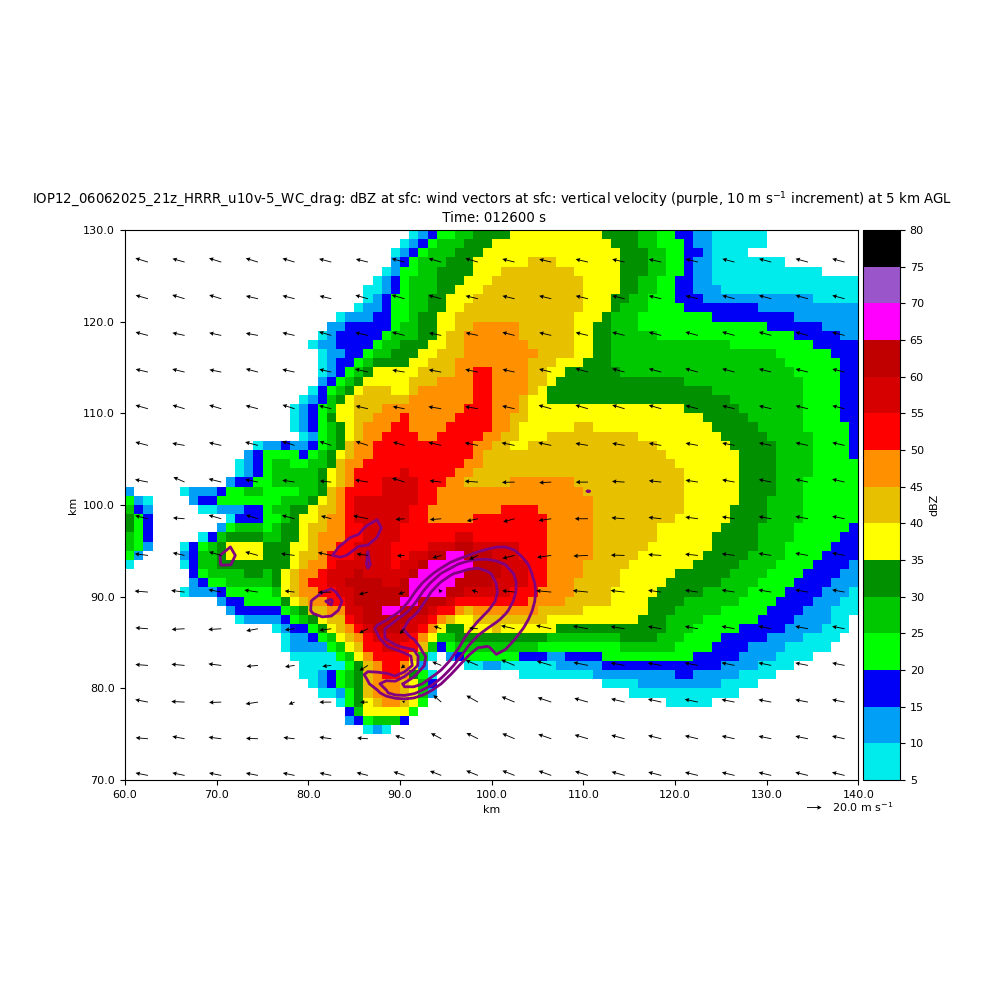

In [10]:
# Pick a time to plot
# The storm structure at this time resembles that of the real storm as it passed over the PIPS
plottime = 12600.
cm1_ds_plt = cm1_ds.sel(time=plottime)

# Set some plotting limits here
plotxlim = [60., 140.] # [70., 150.] # [60., 140.]
plotylim = [70., 130.] # [40., 100.] # [65., 125.]

# Let's plot the reflectivity and wind vectors at the surface, and the the vertical velocity at ~ 5 km.

# Note, using "isel()" below will slice on the *index* of the given coordinate. So isel(zh=0) will choose the
# first height in the scalar height array, which is the first height level above ground for the scalar points
usfc = cm1_ds_plt['uinterp'].isel(zh=0)
vsfc = cm1_ds_plt['vinterp'].isel(zh=0)
dBZsfc = cm1_ds_plt['dbz'].isel(zh=0)
# In contrast, using the sel() method will slice on the *value* of the given coordinate. Additionally you can
# use the method='nearest' keyword argument to choose the closest coordinate value to the one given.
# So, in the following, sel(zh=5., method='nearest') will choose the zh coordinate closest to the value of 5 km.
w5km = cm1_ds_plt['winterp'].sel(zh=5., method='nearest')

clevels = np.arange(5.0, 85.0, 5.0)  # Contour levels for the reflectivity plot.
                                   # Here we are contouring at 5 dBZ intervals from 5.0 dBZ to 80.0 dBZ

# Note, for pcolor plots, the pcolormesh function expects to be given the corner points of the quadrilateral
# surrounding each field point. This means we need to do some special handling of the coordinate arrays for
# this type of plot. Specifically, this means that if one is trying to plot a variable that lives on the
# scalar points (those dimensioned by xh, yh, zh), then one has to pass in the appropriate staggered grid
# coordinates using the xcor and ycor arguments. So, for a horizontal 2D slice, these would be the xf and yf
# coordinates. These have to be the actual coordinates extracted from the original Dataset, since the
# DataArray holding the variable to be plotted won't have those coordinates. So in the call below we pass
# xcor=cm1_sub_ds_plt['xf'] and ycor=cm1_sub_ds_plt['yf']. For all other plot types, we can just use the
# coordinates associated with the DataArray itself (see contour plot below)

fig, ax, plot_handle = plotmod.plot2D(dBZsfc, xcor=cm1_ds_plt['xf'], ycor=cm1_ds_plt['yf'],
                                      ptype='pcolor', field_levels=clevels, cmap=cmapdBZ, cbar_levels=clevels,
                                      cbar_label='dBZ')
# Add wind vectors to the plot, first thinning them by a factor of 2.
uvec = plotmod.thin_2D(usfc, xintv=windintv, yintv=windintv)
vvec = plotmod.thin_2D(vsfc, xintv=windintv, yintv=windintv)
Q = plotmod.add_wind_vectors(ax, uvec, vvec, keypos=(0.95, -0.05))
# Now overlay the vertical velocity at 5 km. Note that this time we pass the figure and axes objects that were
# created in the first call to plot2D into this call, so that it knows to add the contours to the same plot.
# Note that here we *do not* use the xcor and ycor arguments, since we are doing a contour plot, which only
# requires the coordinates of the field we are plotting that is already stored in the DataArray passed in
# (in this case, 'w5km'). Instead we use xname='xh' and yname='yh' which is used inside the plot2D function to
# extract the associated coordinates. This is similar to how xarray's bulit-in plotting functions work.
wclevels = np.arange(10., 50., 10.)
colors = ['purple']
lw = 2
fig, ax, plot_handle = plotmod.plot2D(w5km, xname='xh', yname='yh', ptype='contour', field_levels=wclevels,
                                      colors=colors, lw=lw, fig=fig, ax=ax)
# Now set the plot axes labels appropriately
# Note that we can use a different x and y axes limits than what we used to subset the Dataset above if we want
# to zoom in even further without actually changing the data. We will do that in the following cell.
plotmod.set_plot_axes(ax, plotxlim, plotylim, data_units='km', axis_label_units='km')

# Create the title for the initial frame
title_level_list = ['sfc', 'sfc', '5 km AGL']
title_field_list = ['dBZ', 'wind vectors', r'vertical velocity (purple, 10 m s$^{-1}$ increment)']

title_string = plotmod.make_title_xy(runname, time=f'{int(plottime):06d} s', level_list=title_level_list,
                                     field_list=title_field_list)

ax.set_title(title_string)

# Save the figure to a file.
plotdir = basedir + 'plots/' + runname
if not os.path.exists(plotdir):
    os.makedirs(plotdir)
figpath = os.path.join(plotdir, runname+'_dBZ_sfc_w_5km_'+f'{int(plottime):06d}'+'.png')
plt.savefig(figpath, dpi=300, bbox_inches='tight')

In [11]:
PIPS_ds_dict

{'PIPS1A': <xarray.Dataset> Size: 18MB
 Dimensions:                    (time: 525, fallspeed_bin: 32, diameter_bin: 32,
                                 parameter: 3)
 Coordinates:
   * time                       (time) datetime64[ns] 4kB 2025-06-06T23:29:20 ...
     fallspeed                  (fallspeed_bin) float64 256B 0.05 0.15 ... 20.8
     diameter                   (diameter_bin) float64 256B 0.0625 ... 24.5
     min_diameter               (diameter_bin) float64 256B 0.0 0.125 ... 23.0
     max_diameter               (diameter_bin) float64 256B 0.125 0.25 ... 26.0
     min_fallspeeds             (fallspeed_bin) float64 256B 0.0 0.1 ... 19.2
     max_fallspeeds             (fallspeed_bin) float64 256B 0.1 0.2 ... 22.4
   * parameter                  (parameter) <U5 60B 'N0' 'lamda' 'alpha'
 Dimensions without coordinates: fallspeed_bin, diameter_bin
 Data variables: (12/96)
     precipintensity            (time) float64 4kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
     precipaccum            

In [12]:
rad_loc_dict

{'PIPS1A': (np.float64(-51995.03431925021),
  np.float64(-11568.611832067145),
  np.float64(41.71395924585795)),
 'PIPS1B': (np.float64(-51658.65115795019),
  np.float64(-24409.026415848726),
  np.float64(27.68947043066146)),
 'PIPS2A': (np.float64(-52079.23643946256),
  np.float64(-17711.099704968317),
  np.float64(41.22932022932014)),
 'PIPS2B': (np.float64(-52117.10853253904),
  np.float64(-20082.642748585156),
  np.float64(34.72878832985998)),
 'PIPS3A': (np.float64(-52025.90421515729),
  np.float64(-13930.50748771445),
  np.float64(68.02886280546477)),
 'PIPS3B': (np.float64(-52062.469348755476),
  np.float64(-16271.072779396798),
  np.float64(74.41543430222669))}

In [13]:
# Make a plot of the PIPS transects through the storm, choosing a representative sweep time as
# the backdrop.
sweeptime_ref = datetime.strptime(reftime_str, '%Y-%m-%dT%H:%M:%S')
# sweeptime_ref = datetime.strptime('20250607001756', '%Y%m%d%H%M%S')
sweepindex = np.searchsorted(sweeptime_list, sweeptime_ref)
sweepdtrel = [(sweeptime - sweeptime_ref).total_seconds() for sweeptime in sweeptime_list]

# Create a dictionary comprehesion for rad_loc_dict to create new lists of x and y locations for
# each PIPS that are adjusted for storm motion at each sweep time relative to the reference time.
# This will be used to plot the PIPS transects in the radar-relative frame, which is more
# appropriate for comparing to the radar sweeps.
rad_xloc_sr_dict = {PIPS_name: [rad_loc_dict[PIPS_name][0] - u_storm * dt for dt in sweepdtrel] for PIPS_name in PIPS_names}
rad_yloc_sr_dict = {PIPS_name: [rad_loc_dict[PIPS_name][1] - v_storm * dt for dt in sweepdtrel] for PIPS_name in PIPS_names}

# Create a dictionary comprehension that flags those times each PIPS was deployed at each
# sweep time, which will be used to determine when to plot each PIPS in the radar-relative frame.
rad_loc_deployed_dict = {PIPS_name: [(np.datetime64(sweep_time) >= PIPS_ds_dict[PIPS_name].time[0].values) and
                                     (np.datetime64(sweep_time) <= PIPS_ds_dict[PIPS_name].time[-1].values)
                                     for sweep_time in sweeptime_list] for PIPS_name in PIPS_names}

In [14]:
# Set up plotting limits for the radar-relative frame plot based on the PIPS locations and a buffer
# zone around them
rad_xloc_sr_list = [rad_xloc_sr_dict[PIPS_name] for PIPS_name in PIPS_names]
rad_yloc_sr_list = [rad_yloc_sr_dict[PIPS_name] for PIPS_name in PIPS_names]

# Find the min and max x and y locations across all PIPS
x_min = min(min(x) for x in rad_xloc_sr_list)
x_max = max(max(x) for x in rad_xloc_sr_list)
y_min = min(min(y) for y in rad_yloc_sr_list)
y_max = max(max(y) for y in rad_yloc_sr_list)

# Round to nearest 10 km on either side for nicer plotting limits (assuming units are in meters).
x_min = 10000 * np.floor(x_min / 10000)
x_max = 10000 * np.ceil(x_max / 10000)
y_min = 10000 * np.floor(y_min / 10000)
y_max = 10000 * np.ceil(y_max / 10000)


plot_xlim = (x_min, x_max)
plot_ylim = (y_min, y_max)
print(plot_xlim, plot_ylim)

(np.float64(-130000.0), np.float64(10000.0)) (np.float64(-40000.0), np.float64(10000.0))


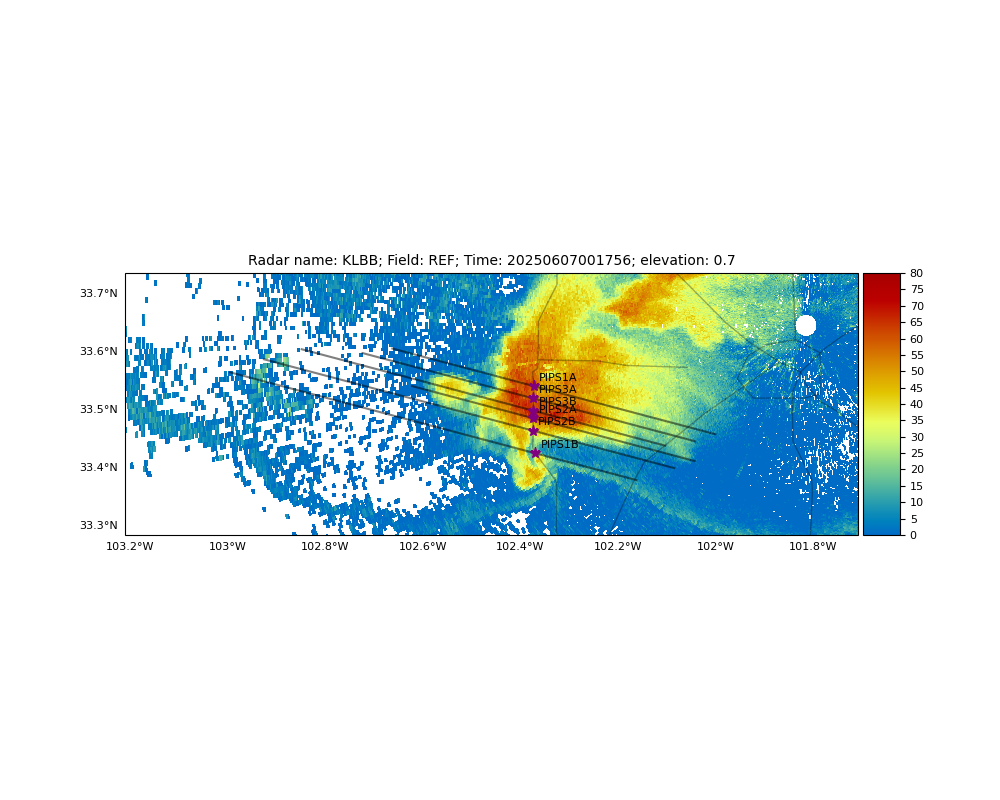

In [15]:
bounds = [plot_xlim[0], plot_xlim[1], plot_ylim[0], plot_ylim[1]]
ref_radar_sweep = radarsweep_list[sweepindex]
figlist, axlist, fields_plotted = \
        radar.plotsweep_pcolor(ref_radar_sweep, ['REF'], sweeptime_ref, plot_filtered=False,
                               bounds=bounds)

for PIPS in PIPS_names:

    PIPS_x_sr = rad_xloc_sr_dict[PIPS]
    PIPS_y_sr = rad_yloc_sr_dict[PIPS]
    PIPS_x_sr_deployed = [x for x, deployed in zip(PIPS_x_sr, rad_loc_deployed_dict[PIPS]) if deployed]
    PIPS_y_sr_deployed = [y for y, deployed in zip(PIPS_y_sr, rad_loc_deployed_dict[PIPS]) if deployed]

    axlist[0].plot(PIPS_x_sr_deployed, PIPS_y_sr_deployed, ls='-', c='k', alpha=0.5)
    axlist[0].plot(PIPS_x_sr[sweepindex], PIPS_y_sr[sweepindex], marker='*', c='purple', ms=8)
    x_text = PIPS_x_sr[sweepindex] + 1000  # Add an offset to the right of the point for the text
    y_text = PIPS_y_sr[sweepindex] + 1000  # Add an offset above the point for the text
    axlist[0].annotate(PIPS, xy=(x_text, y_text), clip_on=True)

    # Save the figure to a file.
plotdir = basedir + 'plots/' + runname
if not os.path.exists(plotdir):
    os.makedirs(plotdir)
figpath = os.path.join(plotdir, radar_name+'_dBZ_sfc_PIPS_transects_'+f'{sweeptime_ref.strftime("%Y%m%d%H%M%S")}'+'.png')
plt.savefig(figpath, dpi=300, bbox_inches='tight')

    # for i, sweep_time in enumerate(sweeptime_list):
    #     if rad_loc_deployed_dict[PIPS][i]:
    #         axlist[0].plot(rad_xloc_sr_dict[PIPS][i], rad_yloc_sr_dict[PIPS][i], 'r*', ms=10, alpha=0.5)
    #         x_text = rad_xloc_sr_dict[PIPS][i] + 5000  # Add an offset to the right of the point for the text
    #         y_text = rad_yloc_sr_dict[PIPS][i] + 5000  # Add an offset above the point for the text
    #         axlist[0].annotate(PIPS, xy=(x_text, y_text))

In [16]:
# Now, we need to identify some reference coordinates from the model that identify a similar feature
# from the reference radar sweep. For example, at the radar reference time, PIPS1B is near the tip of the
# hook echo, so we can identify the coordinates of the tip of the hook echo in the model at the
# model reference time and use those to place the PIPS transects in the model-relative frame.
# To do this, we can use the same storm motion correction
xref_mod = 91600.  # x coordinate of the tip of the hook echo in the model at the reference time
yref_mod = 81000.  # y coordinate of the tip of the hook echo in the model at the reference time
modeltime_sec_ref = 12600.

xref_rad = rad_xloc_sr_dict['PIPS1B'][sweepindex]
yref_rad = rad_yloc_sr_dict['PIPS1B'][sweepindex]

xshift = xref_mod - xref_rad
yshift = yref_mod - yref_rad

rad_xloc_shifted_dict = {PIPS_name: [x + xshift for x in rad_xloc_sr_dict[PIPS_name]] for PIPS_name in PIPS_names}
rad_yloc_shifted_dict = {PIPS_name: [y + yshift for y in rad_yloc_sr_dict[PIPS_name]] for PIPS_name in PIPS_names}

# Now we can plot the PIPS transects in the model-relative frame using the shifted coordinates.


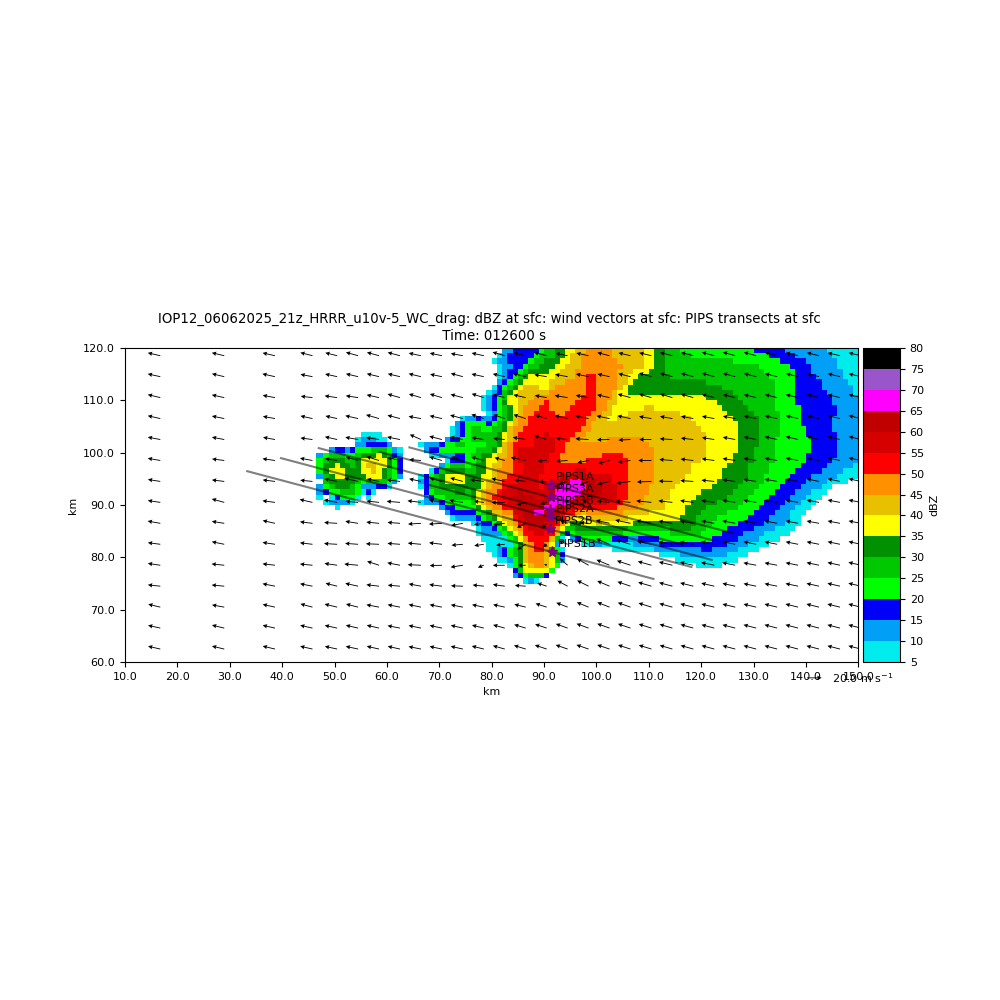

In [17]:
# Pick a time to plot
# The storm structure at this time resembles that of the real storm as it passed over the PIPS

plottime = modeltime_sec_ref
cm1_ds_plt = cm1_ds.sel(time=plottime)

# Set up plotting limits for the radar-relative frame plot based on the PIPS locations and a buffer
# zone around them
rad_xloc_shifted_list = [rad_xloc_shifted_dict[PIPS_name] for PIPS_name in PIPS_names]
rad_yloc_shifted_list = [rad_yloc_shifted_dict[PIPS_name] for PIPS_name in PIPS_names]

# Find the min and max x and y locations across all PIPS
x_min_mod = min(min(x) for x in rad_xloc_shifted_list)
x_max_mod = max(max(x) for x in rad_xloc_shifted_list)
y_min_mod = min(min(y) for y in rad_yloc_shifted_list)
y_max_mod = max(max(y) for y in rad_yloc_shifted_list)

# Round to nearest 10 km on either side for nicer plotting limits (assuming units are in meters).
x_min_mod = 10000 * np.floor(x_min_mod / 10000)
x_max_mod = 10000 * np.ceil(x_max_mod / 10000)
y_min_mod = 10000 * np.floor(y_min_mod / 10000)
y_max_mod = 10000 * np.ceil(y_max_mod / 10000)

plotxlim = [x_min_mod / 1000., x_max_mod / 1000.] # Convert to km for plotting
plotylim = [y_min_mod / 1000., y_max_mod / 1000.] # Convert to km for plotting

# Set some plotting limits here
# plotxlim = [60., 140.] # [70., 150.] # [60., 140.]
# plotylim = [70., 130.] # [40., 100.] # [65., 125.]

# Let's plot the reflectivity and wind vectors at the surface, and the the vertical velocity at ~ 5 km.

# Note, using "isel()" below will slice on the *index* of the given coordinate. So isel(zh=0) will choose the
# first height in the scalar height array, which is the first height level above ground for the scalar points
usfc = cm1_ds_plt['uinterp'].isel(zh=0)
vsfc = cm1_ds_plt['vinterp'].isel(zh=0)
dBZsfc = cm1_ds_plt['dbz'].isel(zh=0)
# In contrast, using the sel() method will slice on the *value* of the given coordinate. Additionally you can
# use the method='nearest' keyword argument to choose the closest coordinate value to the one given.
# So, in the following, sel(zh=5., method='nearest') will choose the zh coordinate closest to the value of 5 km.
# w5km = cm1_ds_plt['winterp'].sel(zh=5., method='nearest')

clevels = np.arange(5.0, 85.0, 5.0)  # Contour levels for the reflectivity plot.
                                   # Here we are contouring at 5 dBZ intervals from 5.0 dBZ to 80.0 dBZ

# Note, for pcolor plots, the pcolormesh function expects to be given the corner points of the quadrilateral
# surrounding each field point. This means we need to do some special handling of the coordinate arrays for
# this type of plot. Specifically, this means that if one is trying to plot a variable that lives on the
# scalar points (those dimensioned by xh, yh, zh), then one has to pass in the appropriate staggered grid
# coordinates using the xcor and ycor arguments. So, for a horizontal 2D slice, these would be the xf and yf
# coordinates. These have to be the actual coordinates extracted from the original Dataset, since the
# DataArray holding the variable to be plotted won't have those coordinates. So in the call below we pass
# xcor=cm1_sub_ds_plt['xf'] and ycor=cm1_sub_ds_plt['yf']. For all other plot types, we can just use the
# coordinates associated with the DataArray itself (see contour plot below)

fig, ax, plot_handle = plotmod.plot2D(dBZsfc, xcor=cm1_ds_plt['xf'], ycor=cm1_ds_plt['yf'],
                                      ptype='pcolor', field_levels=clevels, cmap=cmapdBZ, cbar_levels=clevels,
                                      cbar_label='dBZ')
# Add wind vectors to the plot, first thinning them by a factor of 2.
uvec = plotmod.thin_2D(usfc, xintv=windintv, yintv=windintv)
vvec = plotmod.thin_2D(vsfc, xintv=windintv, yintv=windintv)
Q = plotmod.add_wind_vectors(ax, uvec, vvec, keypos=(0.95, -0.05))
# Now overlay the vertical velocity at 5 km. Note that this time we pass the figure and axes objects that were
# created in the first call to plot2D into this call, so that it knows to add the contours to the same plot.
# Note that here we *do not* use the xcor and ycor arguments, since we are doing a contour plot, which only
# requires the coordinates of the field we are plotting that is already stored in the DataArray passed in
# (in this case, 'w5km'). Instead we use xname='xh' and yname='yh' which is used inside the plot2D function to
# extract the associated coordinates. This is similar to how xarray's bulit-in plotting functions work.
# wclevels = np.arange(10., 50., 10.)
# colors = ['purple']
# lw = 2
# fig, ax, plot_handle = plotmod.plot2D(w5km, xname='xh', yname='yh', ptype='contour', field_levels=wclevels,
#                                       colors=colors, lw=lw, fig=fig, ax=ax)
# Now set the plot axes labels appropriately
# Note that we can use a different x and y axes limits than what we used to subset the Dataset above if we want
# to zoom in even further without actually changing the data. We will do that in the following cell.
plotmod.set_plot_axes(ax, plotxlim, plotylim, data_units='km', axis_label_units='km')

# Create the title for the initial frame
title_level_list = ['sfc', 'sfc', 'sfc'] # '5 km AGL']
title_field_list = ['dBZ', 'wind vectors', 'PIPS transects'] # , r'vertical velocity (purple, 10 m s$^{-1}$ increment)']

title_string = plotmod.make_title_xy(runname, time=f'{int(plottime):06d} s', level_list=title_level_list,
                                     field_list=title_field_list)

ax.set_title(title_string)

for PIPS in PIPS_names:

    PIPS_x_sr = rad_xloc_shifted_dict[PIPS]
    PIPS_y_sr = rad_yloc_shifted_dict[PIPS]
    PIPS_x_sr = np.array(PIPS_x_sr) / 1000.  # Convert to km for plotting
    PIPS_y_sr = np.array(PIPS_y_sr) / 1000.  # Convert to km for plotting
    PIPS_x_sr_deployed = [x for x, deployed in zip(PIPS_x_sr, rad_loc_deployed_dict[PIPS]) if deployed]
    PIPS_y_sr_deployed = [y for y, deployed in zip(PIPS_y_sr, rad_loc_deployed_dict[PIPS]) if deployed]

    ax.plot(PIPS_x_sr_deployed, PIPS_y_sr_deployed, ls='-', c='k', alpha=0.5)
    ax.plot(PIPS_x_sr[sweepindex], PIPS_y_sr[sweepindex], marker='*', c='purple', ms=8)
    x_text = PIPS_x_sr[sweepindex] + 1.  # Add an offset to the right of the point for the text
    y_text = PIPS_y_sr[sweepindex] + 1.  # Add an offset above the point for the text
    ax.annotate(PIPS, xy=(x_text, y_text), clip_on=True)

# Save the figure to a file.
plotdir = basedir + 'plots/' + runname
if not os.path.exists(plotdir):
    os.makedirs(plotdir)
figpath = os.path.join(plotdir, runname+'_dBZ_sfc_PIPS_transects_'+f'{int(plottime):06d}'+'.png')
plt.savefig(figpath, dpi=300, bbox_inches='tight')

In [18]:
# Testing the sim module functions for finding transect-grid intersections
# First look at PIPS1A

PIPS1A_xy_model_loc = (rad_xloc_shifted_dict['PIPS1A'][sweepindex], rad_yloc_shifted_dict['PIPS1A'][sweepindex])
print(PIPS1A_xy_model_loc)
PIPS_times = pips.get_datetimes(PIPS_ds_dict['PIPS1A'])

# Convert cm1_ds to canonical form for use in sim module functions
cm1_cfg = model_config.make_config("CM1")
cm1_ds_plt_norm = model_config.normalize(cm1_ds_plt, cm1_cfg, rename_vars=False)
# cm1_ds_plt_norm
# Find grid intersections
transect_ds = sim.find_transect_grid_intersections(cm1_ds_plt_norm, PIPS_times,
                                                   PIPS1A_xy_model_loc, sweeptime_ref,
                                                   u_storm, v_storm)

(np.float64(91263.61683869999), np.float64(93840.41458378159))


In [19]:
transect_grid_indices_ds = sim.get_transect_grid_indices(transect_ds, cm1_ds_plt_norm,
                                                         modeltime_sec_ref)

In [20]:
Nc_bin_ps = sim.sample_model_PSD_along_transect(transect_ds, cm1_ds_plt_norm, transect_grid_indices_ds)

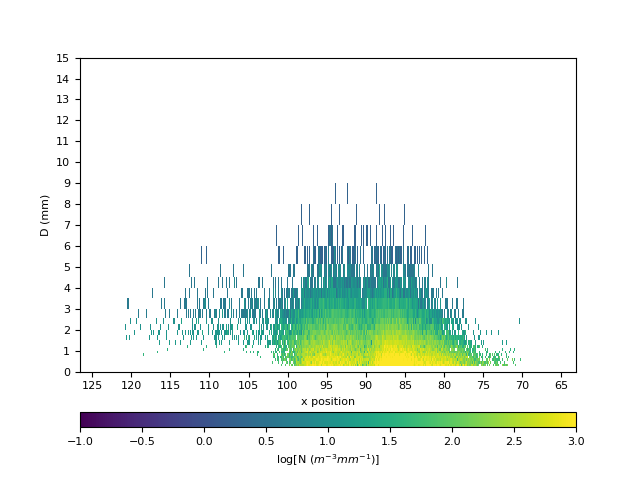

In [21]:
Nc_bin_ps_plt = np.ma.masked_invalid(Nc_bin_ps['Nc_bin_ps'].values)
logNc_bin_ps = np.log10(Nc_bin_ps_plt)
logNc_bin_ps = np.ma.masked_where(logNc_bin_ps <= -1.0, logNc_bin_ps)

plotparamdicts = [{'type': 'pcolor', 'vlimits': (-1.0, 3.0), 'clabel': r'log[N ($m^{-3} mm^{-1}$)]'}]
xvals = [transect_ds['x_sample'] / 1000.]
yvals = [pp.parsivel_parameters['avg_diameter_bins_mm']] # [Dl[:Dmax_index+1]*1000.]
zvals = [logNc_bin_ps.T]
ax = PIPSplot.plotmeteogram(None, xvals, zvals, plotparamdicts, yvals=yvals)
axparamdicts = [{'majorxlocator': ticker.MultipleLocator(base=5.0),
                 'majorylocator': ticker.MultipleLocator(base=1.0),
                 'axeslimits': [None, (0.0, 15.0)],
                 'axeslabels': ['x position', 'D (mm)']}]
axlist = PIPSplot.set_meteogram_axes([ax], axparamdicts)
for ax in axlist:
    ax.invert_xaxis()

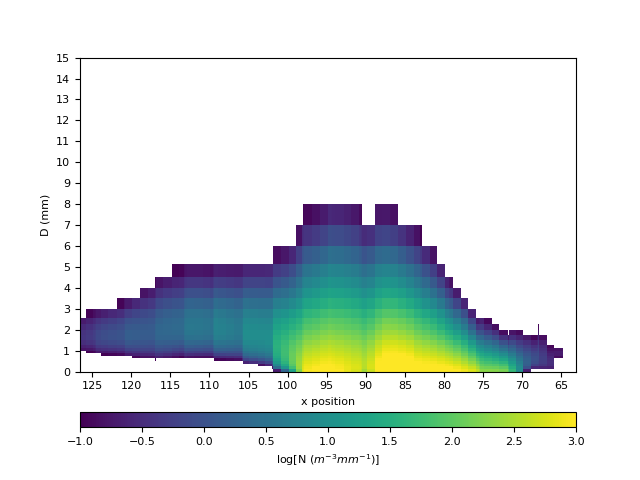

In [22]:
# Now compute and plot the DSD meteograms using the full model DSD instead of the sampled PSD along
# the transect.

Nc_bin = sim.calc_model_PSD_along_transect(transect_ds, cm1_ds_plt_norm, transect_grid_indices_ds)
Nc_bin_plt = np.ma.masked_invalid(Nc_bin['ND_model'].values)
logNc_bin = np.log10(Nc_bin_plt)
logNc_bin = np.ma.masked_where(logNc_bin <= -1.0, logNc_bin)

plotparamdicts = [{'type': 'pcolor', 'vlimits': (-1.0, 3.0), 'clabel': r'log[N ($m^{-3} mm^{-1}$)]'}]
xvals = [transect_ds['x_sample'] / 1000.]
yvals = [pp.parsivel_parameters['avg_diameter_bins_mm']] # [Dl[:Dmax_index+1]*1000.]
zvals = [logNc_bin.T]
ax = PIPSplot.plotmeteogram(None, xvals, zvals, plotparamdicts, yvals=yvals)
axparamdicts = [{'majorxlocator': ticker.MultipleLocator(base=5.0),
                 'majorylocator': ticker.MultipleLocator(base=1.0),
                 'axeslimits': [None, (0.0, 15.0)],
                 'axeslabels': ['x position', 'D (mm)']}]
axlist = PIPSplot.set_meteogram_axes([ax], axparamdicts)
for ax in axlist:
    ax.invert_xaxis()